# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [1]:
import pandas as pd
import statistics as st
import collections as col

from util import utils as ut

In [2]:
obj_data = pd.read_csv('./exercicios_resolvidos/data/aa_count.csv', index_col='Unnamed: 0')
obj_data

,isg15,hur,ifna,tnfa,atpsf1a
Alanine,7,23,11,50,58
Arginine,8,20,10,56,38
Asparagine,4,23,4,40,16
Aspartic Acid,7,16,8,30,29
Cysteine,1,3,6,40,2
Glutamic Acid,9,15,14,57,31
Glutamine,12,12,12,39,25
Glycine,18,29,6,45,51
Histidine,3,8,3,30,7
Isoleucine,3,19,8,27,39


In [3]:
def tendencia_central(serie: pd.Series) -> dict:
    '''
        Função que recebe uma objeto composto unidimencinal e retorna medidas de tendência central.
            Parâmetro:
                serie = objeto composto unidimencinal
            Retorno:
                Dicionário contendo a média, a mediana e a moda.
    '''
    serie_media = round(st.mean(serie), 4)
    serie_mediana = round(st.median(serie), 4)
    data = dict(col.Counter(serie))
    valor = 2
    for k, v in data.items():
        if valor < v:
            valor = v
    serie_moda = []
    for k, v in data.items():
        if valor == v:
            serie_moda.append([k,v])
    retorno_dic = {
        'Media': serie_media,
        'Mediana': serie_mediana,
        'Moda': serie_moda
    }
    return retorno_dic

In [4]:
ut.printLis(obj_data.index)

-------------
-=< Lista >=-
-------------
0 -> Alanine
1 -> Arginine
2 -> Asparagine
3 -> Aspartic Acid
4 -> Cysteine
5 -> Glutamic Acid
6 -> Glutamine
7 -> Glycine
8 -> Histidine
9 -> Isoleucine
10 -> Leucine
11 -> Lysine
12 -> Methionine
13 -> Phenylalanine
14 -> Proline
15 -> Serine
16 -> Threonine
17 -> Tryptophan
18 -> Tyrosine
19 -> Valine


In [5]:
tendencia_central(obj_data.loc[obj_data.index[15]])

{'Media': 30.6, 'Mediana': 28, 'Moda': []}

In [6]:
ut.printLis(obj_data.columns)

-------------
-=< Lista >=-
-------------
0 -> isg15
1 -> hur
2 -> ifna
3 -> tnfa
4 -> atpsf1a


In [7]:
tendencia_central(obj_data.loc[:, obj_data.columns[2]])

{'Media': 9.4, 'Mediana': 9.0, 'Moda': [[11, 4]]}

## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [8]:
 def amplitude(serie: pd.Series) -> float:
    '''
        Função que recebe uma objeto composto unidimencinal e retorna a amplitude.
            Parâmetro:
                serie = objeto composto unidimencinal
            Retorno:
                Objeto simples contendo a amplitude.
    '''
    return max(list(serie)) - min(list(serie))

In [9]:
amplitude(obj_data.loc['Isoleucine'])

36

In [10]:
print(obj_data.columns[-1])
amplitude(obj_data[obj_data.columns[-1]])

atpsf1a


58

## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [11]:
 def quartis(serie: pd.Series) -> dict:
    '''
        Função que recebe uma objeto composto unidimencinal e retorna os quartis.
            Parâmetro:
                serie = objeto composto unidimencinal
            Retorno:
                Dicionário contendo o Q1, Q2 e Q3.
    '''
    serie = list(serie)
    serie.sort()
    quartil_1 = st.median(serie)
    index_meio = len(serie)//2
    quartil_2 = st.median(serie[:index_meio])
    quartil_3 = st.median(serie[index_meio:])
    retorno_dic = {
      'Q1': quartil_1,
      'Q2': quartil_2,
      'Q3': quartil_3
    }
    return retorno_dic

In [12]:
quartis(obj_data.loc['Methionine'])

{'Q1': 10, 'Q2': 5.0, 'Q3': 12}

In [13]:
print(obj_data.columns[0])
quartis(obj_data[obj_data.columns[0]])

isg15


{'Q1': 7.5, 'Q2': 3.5, 'Q3': 10.5}

## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [14]:
def interquartil(serie: pd.Series) -> float:
    '''
        Função que recebe uma objeto composto unidimencinal e retorna o intervalo interquartil.
            Parâmetro:
                serie = objeto composto unidimencinal
            Retorno:
                Objeto simples contendo o intervalo interquartil.
    '''
    serie = list(serie)
    serie.sort()
    quartil_1 = st.median(serie)
    index_meio = len(serie)//2
    quartil_2 = st.median(serie[:index_meio])
    quartil_3 = st.median(serie[index_meio:])
    return quartil_3- quartil_1

In [15]:
interquartil(obj_data.loc['Glutamic Acid'])

16

In [16]:
print(obj_data.columns[-2])
interquartil(obj_data[obj_data.columns[-2]])

tnfa


11.5

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

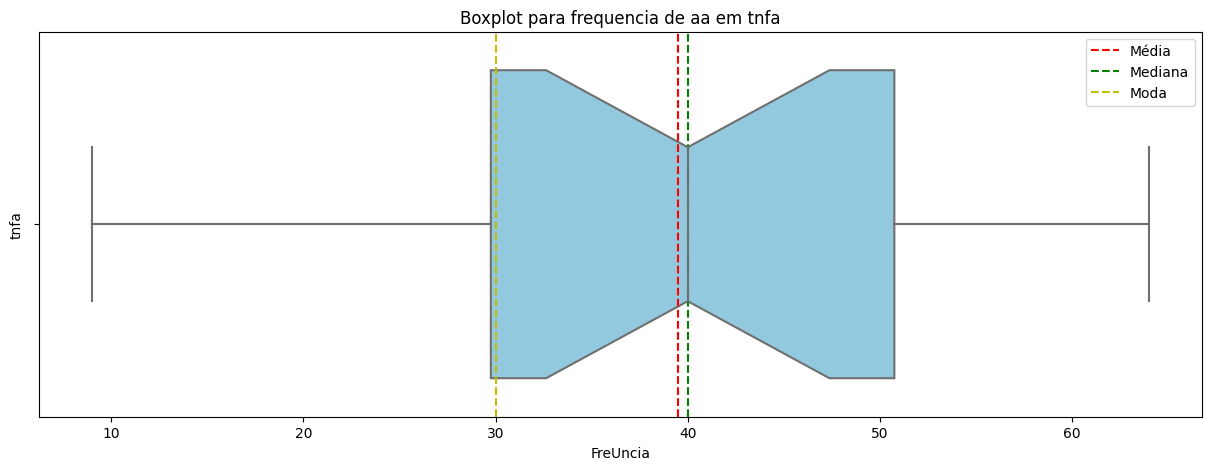

In [49]:
coluna = -2
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(
    x=obj_data.columns[coluna],
    ax=ax,
    notch=True,
    color='skyblue',
    data=obj_data,
)
plt.axvline(obj_data[obj_data.columns[coluna]].mean(), color='r', linestyle='--', label='Média')
plt.axvline(obj_data[obj_data.columns[coluna]].median(), color='g', linestyle='--', label='Mediana')
plt.axvline(obj_data[obj_data.columns[coluna]].mode()[0], color='y', linestyle='--', label='Moda')
plt.legend()
plt.title(f"Boxplot para frequencia de aa em {obj_data.columns[coluna]}")
plt.xlabel("FreUncia")
plt.ylabel(f"{obj_data.columns[coluna]}")
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [17]:
def variancia(serie: pd.Series) -> float:
    '''
        Função que recebe uma objeto composto unidimencinal e retorna a variância amostral não viciada.
        Parâmetro:
            serie = objeto composto unidimencinal
        Retorno:
            Objeto simples contendo a variância.
    '''
    serie_soma = []
    for num in serie:
        serie_soma.append(round((num- st.mean(serie))**2, 2))
    return round(sum(serie_soma)/(len(serie)- 1), 3)

In [18]:
variancia(obj_data.loc['Proline'])

433.2

In [19]:
print(obj_data.columns[2])
variancia(obj_data[obj_data.columns[2]])

ifna


32.884

## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [20]:
def desvio_padrao(serie: pd.Series) -> float:
    '''
        Função que recebe uma objeto composto unidimencinal e retorna o desvio padrão.
            Parâmetro:
                serie = objeto composto unidimencinal
            Retorno:
                Objeto simples contendo o desvio padrão.
    '''
    serie_soma = []
    for num in serie:
        serie_soma.append(round((num- st.mean(serie))**2, 2))
    return round((sum(serie_soma)/(len(serie)- 1))**0.5, 3)

In [21]:
desvio_padrao(obj_data.loc['Tryptophan'])

3.464

In [22]:
print(obj_data.columns[-1])
desvio_padrao(obj_data[obj_data.columns[-1]])

atpsf1a


16.906

## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [26]:
def coeficiente_varia(serie: pd.Series) -> float:
    '''
        Função que recebe uma objeto composto unidimencinal e retorna o coeficiente de variação.
            Parâmetro:
                serie = objeto composto unidimencinal
            Retorno:
                Objeto simples contendo o coeficiente de variação.
    '''
    serie_soma = []
    for num in serie:
        serie_soma.append(round((num- st.mean(serie))**2, 2))
    desv_padr = round((sum(serie_soma)/(len(serie)- 1))**0.5, 3)
    return round((desv_padr/st.mean(serie))*100, 2)

In [27]:
coeficiente_varia(obj_data.loc['Leucine'])

50.52

In [28]:
print(obj_data.columns[1])
coeficiente_varia(obj_data[obj_data.columns[1]])

hur


45.57

## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [ ]:
def dispersao(serie: pd.Series) -> dict:
    '''
        Função que recebe uma objeto composto unidimencinal e retorna as medidas resumo.
            Parâmetro:
                serie = objeto composto unidimencinal
            Retorno:
                Dicionário onde os index são os nomes e os valores as medidas..
    '''
    medidas = {
        'tendencia_central': tendencia_central(serie),
        'amplitude': amplitude(serie),
        'quartis': quartis(serie),
        'interquartil': interquartil(serie),
        'variancia': variancia(serie),
        'desvio_padrao': desvio_padrao(serie),
        'coeficiente_varia': coeficiente_varia(serie)
    }
    return medidas

## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [30]:
 def disperso_gene(data_frame):
    '''
        Função que recebe uma DataFrame e calcula o coeficiente de dispersão.
            Paraâmetros:
                DataFrame.
            Retorno:
                Gene com o maior coeficiente de dispersão em relação aos aminoácidos.
    '''
    obj_data = data_frame
    lista_coeficiente = [coeficiente_varia(obj_data[valor]) for valor in obj_data.columns]
    coef_max = max(lista_coeficiente)
    index_coef_max = lista_coeficiente.index(coef_max)
    return obj_data.columns[index_coef_max]

In [31]:
disperso_gene(obj_data)

'isg15'

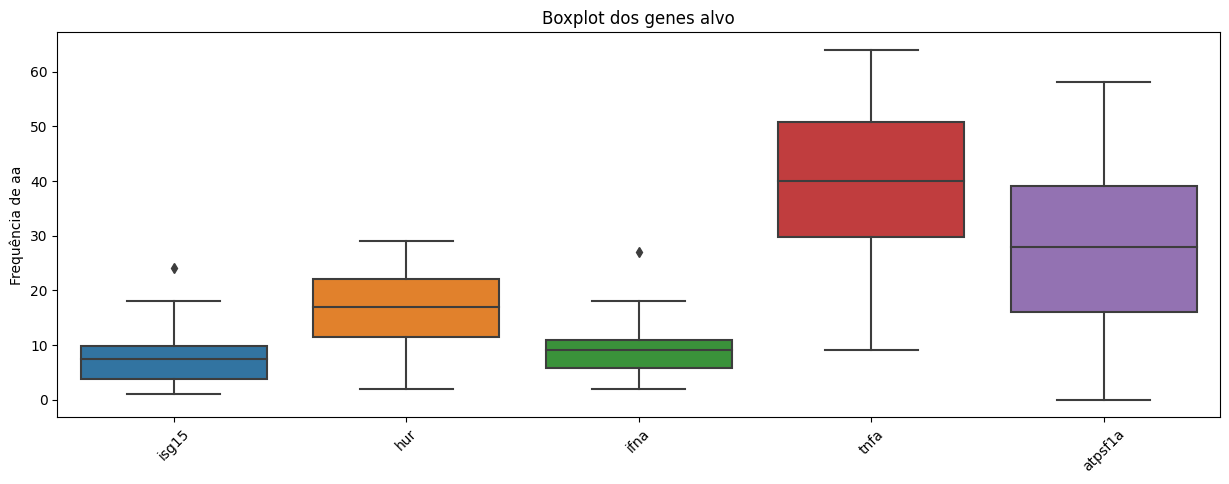

In [61]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(
    ax=ax,
    data=obj_data
)
plt.xticks(rotation=45)
plt.title("Boxplot dos genes alvo")
plt.ylabel("Frequência de aa")
plt.show()

R.: Sim, pela presença do outlier.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [52]:
def disperso_aa(data_frame: pd.DataFrame) -> str:
    '''
        Função que recebe uma DataFrame e calcula o coeficiente de dispersão.
            Paraâmetros:
                DataFrame.
            Retorno:
                aminoácido com o maior coeficiente de dispersão em relação aos genes.
    '''
    obj_data = data_frame
    lista_coeficiente = [coeficiente_varia(obj_data.loc[valor]) for valor in obj_data.index]
    coef_max = max(lista_coeficiente)
    index_coef_max = lista_coeficiente.index(coef_max)
    return obj_data.index[index_coef_max]

In [33]:
disperso_aa(obj_data)

'Cysteine'

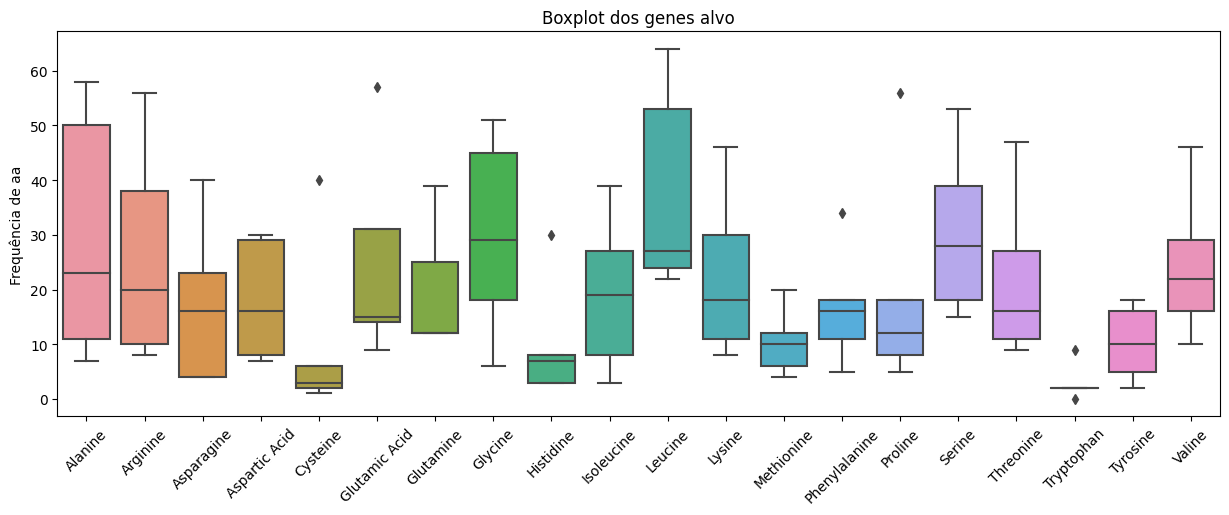

In [51]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(
    ax=ax,
    data=obj_data.T
)
plt.xticks(rotation=45)
plt.title("Boxplot dos genes alvo")
plt.ylabel("Frequência de aa")
plt.show()

R.: Sim, pela presença do outlier.